<a href="https://www.kaggle.com/code/ferhat00/copper-spot-commodities-forecasting?scriptVersionId=309207839" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🟤 Copper Spot Price Forecasting — Kaggle Edition

**Kaggle-optimised build** of the `copper-forecast` repository.

### Prerequisites (Kaggle notebook settings)
| Setting | Value |
|---|---|
| **Accelerator** | GPU T4 x2 (strongly recommended) |
| **Internet** | On |
| **Persistence** | Files only |
| **Secrets** | `FRED_API_KEY`, `NASDAQ_DATA_LINK_API_KEY` (optional but recommended) |

### Speed improvements vs local run
- XGBoost / LightGBM use **CUDA GPU** when a GPU is detected
- Optuna runs **parallel trials** (`n_jobs=-1` on all CPU cores)
- Walk-forward CV uses **`joblib` parallelism**
- Downloaded data is **cached to disk**; re-runs skip the network round-trip
- Reduced `cv_step_size` window to keep memory within 16 GB

## 0. Environment Setup

In [3]:
# ── Clone the repo (skip if already present) ──────────────────────────────
import os, subprocess, sys

REPO_URL  = 'https://github.com/ferhat00/copper-forecast.git'
REPO_DIR  = '/kaggle/working/copper-forecast'

if not os.path.isdir(REPO_DIR):
    result = subprocess.run(
        ['git', 'clone', '--depth', '1', REPO_URL, REPO_DIR],
        capture_output=True, text=True
    )
    print(result.stdout or 'Cloned OK')
    if result.returncode != 0:
        raise RuntimeError(f'git clone failed:\n{result.stderr}')
else:
    print('Repo already present — pulling latest changes…')
    subprocess.run(['git', '-C', REPO_DIR, 'pull', '--ff-only'],
                   capture_output=True)
    print('Up to date.')

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)
print(f'Working directory: {os.getcwd()}')

Cloned OK
Working directory: /kaggle/working/copper-forecast


In [33]:
# ── Install / upgrade required packages ───────────────────────────────────
# Most scientific packages are pre-installed on Kaggle;
# only the domain-specific ones need installation.
import subprocess, sys

_PKGS = [
    'yfinance>=0.2.36',
    'fredapi>=0.5.1',
    'prophet>=1.1.5',
    'hmmlearn>=0.3.0',
    'nasdaq-data-link>=1.0.4',
    'optuna>=3.4.0',
    'shap>=0.43.0',
    'kaleido=0.2.1',
]

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '--quiet', '--upgrade'] + _PKGS,
    check=True
)
print('All packages installed.')

ERROR: Invalid requirement: 'kaleido=0.2.1': Expected end or semicolon (after name and no valid version specifier)
    kaleido=0.2.1
           ^
Hint: = is not a valid operator. Did you mean == ?


CalledProcessError: Command '['/usr/bin/python3', '-m', 'pip', 'install', '--quiet', '--upgrade', 'yfinance>=0.2.36', 'fredapi>=0.5.1', 'prophet>=1.1.5', 'hmmlearn>=0.3.0', 'nasdaq-data-link>=1.0.4', 'optuna>=3.4.0', 'shap>=0.43.0', 'kaleido=0.2.1']' returned non-zero exit status 1.

In [34]:
!pip install kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 18.7 MB/s eta 0:00:0000:01:00:01
  Attempting uninstall: kaleido
    Found existing installation: kaleido 1.2.0
    Uninstalling kaleido-1.2.0:
      Successfully uninstalled kaleido-1.2.0


In [6]:
# ── Detect GPU and configure accelerator flags ────────────────────────────
import subprocess

def _has_gpu() -> bool:
    try:
        out = subprocess.run(
            ['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'],
            capture_output=True, text=True, timeout=5
        )
        return out.returncode == 0 and out.stdout.strip() != ''
    except FileNotFoundError:
        return False

GPU_AVAILABLE = _has_gpu()

# XGBoost: 'hist' on CPU, 'gpu_hist' → deprecated in XGB 2.x; use device='cuda'
XGB_DEVICE   = 'cuda' if GPU_AVAILABLE else 'cpu'
XGB_METHOD   = 'hist'               # 'hist' works on both CPU and CUDA in XGB 2.x

# LightGBM: 'gpu' device when available
LGB_DEVICE   = 'gpu' if GPU_AVAILABLE else 'cpu'

# Joblib concurrency
import os
N_JOBS = int(os.cpu_count() or 2)

print(f'GPU available : {GPU_AVAILABLE}')
print(f'XGBoost device: {XGB_DEVICE} | tree_method: {XGB_METHOD}')
print(f'LightGBM device: {LGB_DEVICE}')
print(f'Parallel jobs : {N_JOBS}')

GPU available : True
XGBoost device: cuda | tree_method: hist
LightGBM device: gpu
Parallel jobs : 4


## 1. Setup & Configuration

In [7]:
import warnings
import logging
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')

from src.data_ingestion import load_data
from src.feature_engineering import build_features, split_features_targets
from src.models import NaiveModel, LinearModel, XGBoostModel, LGBMModel, EnsembleModel, QuantileForecaster
from src.models_arimax import ARIMAXModel
from src.models_hybrid import HybridModel
from src.models_stacking import StackingEnsemble
from src.evaluation import compute_metrics, walk_forward_cv, compare_models, out_of_sample_backtest
from src.visualization import (
    plot_price_history, plot_feature_correlations, plot_cv_results,
    plot_forecast_with_ci, plot_model_comparison, plot_shap_summary,
    plot_scenario_tornado, plot_dashboard, plot_regime_overlay,
)
from src.scenario_analysis import ScenarioEngine, SCENARIO_TEMPLATES
from src.cointegration import add_cointegration_features
from src.regime_detection import RegimeDetector
from src.feature_pruning import auto_prune_features

try:
    from src.models_prophet import ProphetModel
    HAS_PROPHET = True
    print('✅ Prophet available')
except ImportError:
    HAS_PROPHET = False
    print('⚠️  Prophet not installed — ProphetModel will be skipped')

print('✅ All imports OK')

✅ Prophet available
✅ All imports OK


In [9]:
# ── Load API keys from Kaggle Secrets ───────────────────────────────────────
import os, shutil

try:
    from kaggle_secrets import UserSecretsClient
    _secrets = UserSecretsClient()
    for _key in ('EIA_API_KEY', 'FRED_API_KEY', 'ALPHA_VANTAGE_API_KEY'):
        try:
            os.environ[_key] = _secrets.get_secret(_key)
            print(f'  Secret loaded: {_key}')
        except Exception:
            print(f'  WARNING: Secret not found: {_key}')
    print('API keys loaded.')
except ImportError:
    print('Not running on Kaggle — skipping secrets loader.')

# ── Copy config.yaml from private Kaggle dataset ─────────────────────────────
REPO = '/kaggle/working/copper-forecast'
CONFIG_DATASET_PATH = '/kaggle/input/datasets/ferhat00/copper-config2/config.yaml'
CONFIG_DEST         = f'{REPO}/config.yaml'

if os.path.exists(CONFIG_DATASET_PATH):
    shutil.copy(CONFIG_DATASET_PATH, CONFIG_DEST)
    print(f'config.yaml copied → {CONFIG_DEST}')
else:
    print('WARNING: config.yaml dataset not attached — using repo default.')
    print('Attach your private dataset via: Notebook → Add Data')

# ── Configuration ─────────────────────────────────────────────────────────────
CFG = {
    'start_date':          '2010-01-01',
    'forecast_horizon':    1,              # 1-month ahead (trading days)
    'all_horizons':        [1, 5, 22, 66],
    'lags':                [1, 5, 22],
    'initial_train_size':  504,             # ~2 years
    'cv_step_size':        22,
    'holdout_size':        252,             # ~1 year OOS backtest
    'ci_alpha':            0.80,
    # ── Kaggle speed-ups (GPU for XGB/LGB) ──────────────────────────────
    'optuna_trials':       50,
    'xgb_device':         XGB_DEVICE,
    'xgb_tree_method':    XGB_METHOD,
    'lgb_device':         LGB_DEVICE,
    # ── API keys ────────────────────────────────────────────────────────
    'fred_api_key':            os.environ.get('FRED_API_KEY', None),
    'eia_api_key':             os.environ.get('EIA_API_KEY', None),
    'alpha_vantage_api_key':   os.environ.get('ALPHA_VANTAGE_API_KEY', None),
    'random_seed':         42,
    'output_dir':          '/kaggle/working/outputs',
}
os.makedirs(CFG['output_dir'], exist_ok=True)
print('Configuration set:')
for k, v in CFG.items():
    if 'key' not in k or v is None:
        print(f'  {k}: {v}')
    else:
        print(f'  {k}: ***')


API keys loaded.
config.yaml copied → /kaggle/working/copper-forecast/config.yaml
Configuration set:
  start_date: 2010-01-01
  forecast_horizon: 1
  all_horizons: [1, 5, 22, 66]
  lags: [1, 5, 22]
  initial_train_size: 504
  cv_step_size: 22
  holdout_size: 252
  ci_alpha: 0.8
  optuna_trials: 50
  xgb_device: cuda
  xgb_tree_method: hist
  lgb_device: gpu
  fred_api_key: None
  eia_api_key: None
  alpha_vantage_api_key: None
  random_seed: 42
  output_dir: /kaggle/working/outputs


## 2. Data Ingestion

- **yfinance** — Copper (HG=F), DXY, Gold, Aluminium, Oil, CNY/USD, S&P 500, Shanghai
- **FRED API** — Industrial production, real yields, inflation breakeven, M2
- **CFTC COT** — Commercial/non-commercial positioning, open interest, speculative ratio

Downloaded data is cached to `/kaggle/working/data_cache.pkl` so restarted sessions skip the network round-trip.

In [10]:
import pickle, hashlib, time

# Cache key — change if you want to force a refresh
_cache_key  = hashlib.md5(
    (CFG['start_date'] + str(CFG['fred_api_key']) + str(CFG['eia_api_key']) + str(CFG['alpha_vantage_api_key'])).encode()
).hexdigest()[:8]
_cache_path = f"/kaggle/working/data_cache_{_cache_key}.pkl"

if os.path.exists(_cache_path):
    print(f'Loading cached data from {_cache_path}…')
    with open(_cache_path, 'rb') as _f:
        df_raw = pickle.load(_f)
    print('  Cache hit.')
else:
    print('Downloading data (first run — will be cached afterwards)…')
    _t0 = time.time()
    df_raw = load_data(
        start=CFG['start_date'],
        fred_api_key=CFG['fred_api_key'],
        eia_api_key=CFG['eia_api_key'],
        alpha_vantage_api_key=CFG['alpha_vantage_api_key'],
        include_cot=True,
    )
    with open(_cache_path, 'wb') as _f:
        pickle.dump(df_raw, _f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f'  Downloaded in {time.time()-_t0:.1f}s — cached to {_cache_path}')

print(f'Dataset shape: {df_raw.shape}')
print(f'Date range: {df_raw.index.min().date()} → {df_raw.index.max().date()}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.tail()

ERROR | HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: GOGL"}}}
ERROR | $GOGL: possibly delisted; no timezone found
ERROR | $X: possibly delisted; no timezone found
ERROR | $ARCH: possibly delisted; no timezone found
ERROR | $NILSY: possibly delisted; no timezone found
ERROR | 
5 Failed downloads:
ERROR | ['USDCLP=X']: OperationalError('database is locked')
ERROR | ['GOGL', 'X', 'ARCH', 'NILSY']: possibly delisted; no timezone found
INFO | yfinance: downloaded 4239 rows for 105 tickers
WARNING | No FRED API key supplied or fredapi unavailable. Generating synthetic placeholder series.
WARNING | COT: No API key or fetch failed. Generating synthetic COT data.
INFO | COT data integrated: 4 columns added
INFO | Combined dataset: 4238 rows × 150 columns


  Downloaded in 9.2s — cached to /kaggle/working/data_cache_5687af8c.pkl
Dataset shape: (4238, 150)
Date range: 2010-01-04 → 2026-04-03
Columns: ['shanghai', 'alcoa', 'agnico', 'aluminium', 'coal_amr', 'antofagasta', 'coal_arch', 'aud_usd', 'dry_bulk_etf', 'bhp', 'coal_btu', 'oil_brent', 'caterpillar', 'oil_wti', 'cleveland_cliffs', 'copper_miners_etf', 'copper_etf', 'base_metals_etf', 'commodity_idx', 'diana_shipping', 'dxy', 'em_etf', 'eagle_bulk', 'ero_copper', 'eur_usd', 'fcx', 'first_quantum', 'franco_nevada', 'china_etf', 'gbp_usd', 'gold', 'gold_miners_etf', 'glencore', 'genco', 'golden_ocean', 'gsci_etf', 'copper_price', 'heating_oil', 'clean_energy_etf', 'latam_etf', 'ivanhoe', 'kinross', 'lumber', 'lithium_etf', 'lundin', 'matson', 'arcelormittal', 'newmont', 'nat_gas', 'anglo_american', 'norilsk', 'nucor', 'nzd_usd', 'palladium', 'commodity_broad2', 'global_miners_etf', 'construction_etf', 'platinum', 'rare_earth', 'rio', 'safe_bulkers', 'star_bulk', 'scco', 'silver', 'silve

,shanghai,alcoa,agnico,aluminium,coal_amr,antofagasta,coal_arch,aud_usd,dry_bulk_etf,bhp,...,consumer_sentiment,inventory_sales,wti_spot,nat_gas_spot,copper_lme_monthly,china_mfg_prod,commercial_net,noncommercial_net,open_interest,spec_ratio
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-30,3923.287109,63.220001,191.860001,3336.25,214.240005,41.209999,NaN,0.685090,9.940,69.019997,...,152.432203,68.299521,96.389272,146.709468,128.502045,113.292692,8084.115189,824.054213,142009.876727,0.349905
2026-03-31,3891.861084,66.330002,202.979996,3405.50,205.270004,44.570000,NaN,0.684590,9.970,72.739998,...,151.190163,67.997897,94.384962,146.704585,128.660292,113.721051,8084.115189,824.054213,142009.876727,0.349905
2026-04-01,3948.552002,72.059998,210.080002,3452.25,198.330002,47.549999,NaN,0.692051,10.325,73.559998,...,152.540214,68.121525,93.464131,146.075406,126.822936,113.690955,8084.115189,824.054213,142009.876727,0.349905
2026-04-02,3919.284912,71.529999,208.539993,3422.00,209.309998,45.930000,NaN,0.692400,10.450,73.239998,...,152.691701,68.825026,92.879888,148.633752,125.898037,112.891631,8084.115189,824.054213,142009.876727,0.349905
2026-04-03,3880.096924,71.529999,208.539993,3422.00,209.309998,45.930000,NaN,0.691150,10.450,73.239998,...,153.685261,70.087817,91.530784,150.539822,125.951399,113.670096,7432.948027,-172.597184,139719.032288,0.365510


In [11]:
df_raw.describe().round(2)

,shanghai,alcoa,agnico,aluminium,coal_amr,antofagasta,coal_arch,aud_usd,dry_bulk_etf,bhp,...,consumer_sentiment,inventory_sales,wti_spot,nat_gas_spot,copper_lme_monthly,china_mfg_prod,commercial_net,noncommercial_net,open_interest,spec_ratio
count,4231.00,4238.00,4238.00,3083.00,1343.00,4237.00,0.0,4238.00,2095.00,4238.00,...,4238.00,4238.00,4238.00,4238.00,4238.00,4238.00,4238.00,4238.00,4238.00,4238.00
mean,2994.11,30.83,50.10,2218.51,162.52,14.08,NaN,0.79,13.35,34.10,...,86.74,55.41,102.82,103.88,107.27,128.50,11482.32,3633.71,159886.44,0.25
std,520.46,12.36,32.53,399.38,91.16,7.81,NaN,0.13,7.27,13.31,...,40.12,34.82,22.68,23.41,22.14,20.25,5314.43,4095.40,17939.60,0.14
min,1950.01,5.23,17.45,1452.00,10.87,4.09,NaN,0.57,3.91,9.45,...,16.13,-12.12,57.46,58.54,68.36,89.54,-3951.07,-6289.78,127022.06,-0.00
25%,2670.69,21.47,32.77,1911.25,115.84,9.08,NaN,0.69,7.72,25.27,...,49.41,18.66,86.04,86.54,90.93,112.12,8451.54,527.28,145955.19,0.12
50%,3049.38,29.32,43.60,2239.50,156.11,11.51,NaN,0.75,10.69,30.18,...,89.12,62.13,101.57,100.35,103.91,130.29,12249.88,3779.93,158639.95,0.25
75%,3306.62,36.90,53.02,2428.25,211.70,17.31,NaN,0.90,18.88,46.67,...,124.51,86.43,120.97,118.23,117.18,142.94,15469.77,7190.69,173709.80,0.38
max,5166.35,90.95,252.19,3873.00,442.21,61.72,NaN,1.10,41.51,81.41,...,165.49,108.98,161.37,158.88,178.39,174.72,21972.03,11896.87,203183.74,0.49


In [12]:
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
audit = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print('Missing data audit:')
print(audit[audit['missing_count'] > 0].to_string()
      if (audit['missing_count'] > 0).any() else 'No missing data')

Missing data audit:
                   missing_count  missing_pct
shanghai                       7          0.2
aluminium                   1155         27.3
coal_amr                    2895         68.3
antofagasta                    1          0.0
coal_arch                   4238        100.0
dry_bulk_etf                2143         50.6
coal_btu                    1890         44.6
copper_miners_etf             76          1.8
copper_etf                   486         11.5
eagle_bulk                  3986         94.1
ero_copper                  2034         48.0
glencore                     545         12.9
genco                       1181         27.9
golden_ocean                4238        100.0
ivanhoe                      727         17.2
lumber                       747         17.6
lithium_etf                  144          3.4
anglo_american              1333         31.5
norilsk                     4238        100.0
palladium                     12          0.3
commodity_broa

## 3. Exploratory Data Analysis

In [13]:
fig_price = plot_price_history(df_raw)
fig_price.show()

In [14]:
import plotly.express as px

corr_all = df_raw.corr()['copper_price'].drop('copper_price').sort_values()
fig_corr_bar = px.bar(
    x=corr_all.values, y=corr_all.index, orientation='h',
    title='Pearson Correlation with Copper Price',
    labels={'x': 'Pearson r', 'y': 'Series'},
    template='plotly_white', color=corr_all.values,
    color_continuous_scale='RdBu', color_continuous_midpoint=0,
)
fig_corr_bar.show()

In [15]:
import plotly.graph_objects as go

log_ret = np.log(df_raw['copper_price'] / df_raw['copper_price'].shift(1)).dropna()
fig_dist = go.Figure()
fig_dist.add_trace(go.Histogram(
    x=log_ret, nbinsx=80, name='Daily log return',
    marker_color='#b87333', opacity=0.75,
))
fig_dist.update_layout(
    title='Distribution of Daily Copper Log Returns',
    xaxis_title='Log Return', yaxis_title='Count',
    template='plotly_white',
)
fig_dist.show()
print(f'Skewness: {log_ret.skew():.3f}  |  Kurtosis: {log_ret.kurt():.3f}')
print(f'Ann. volatility: {log_ret.std() * np.sqrt(252):.1%}')

Skewness: -1.122  |  Kurtosis: 21.592
Ann. volatility: 23.7%


## 4. Cointegration Analysis & Regime Detection

In [16]:
df_aug, coint_results = add_cointegration_features(df_raw)

coint_df = pd.DataFrame(coint_results).T
print('── Cointegration Test Results (Engle-Granger) ──')
print(coint_df.to_string())
print(f'\nCointegrated pairs: {[k for k, v in coint_results.items() if v["is_cointegrated"]]}')
print(f'ECT columns added: {[c for c in df_aug.columns if c.startswith("ect_")]}')

INFO | Cointegration test: t=-2.725  p=0.1907  beta=1.9636  cointegrated=False
INFO | Cointegration test: t=-3.194  p=0.0709  beta=4.1745  cointegrated=False
INFO | Cointegration: column 'oil' not in DataFrame, skipping
INFO | Cointegration test: t=-1.245  p=0.8458  beta=6.3999  cointegrated=False
INFO | Cointegration: column 'cny_usd' not in DataFrame, skipping


── Cointegration Test Results (Engle-Granger) ──
              column is_cointegrated   p_value      beta
gold            gold           False    0.1907  1.963572
aluminium  aluminium           False  0.070872  4.174527
dxy              dxy           False  0.845833  6.399872

Cointegrated pairs: []
ECT columns added: []


In [17]:
feats_prelim = build_features(df_aug, lags=CFG['lags'], horizons=CFG['all_horizons'])

n_holdout = CFG['holdout_size']
regime_detector = RegimeDetector(n_regimes=3)

try:
    regime_detector.fit(feats_prelim.iloc[:-n_holdout])
    regime_labels = regime_detector.predict(feats_prelim)
    print(f'Regime distribution:\n{regime_labels.value_counts().sort_index()}')
    fig_regime = plot_regime_overlay(df_aug['copper_price'], regime_labels)
    fig_regime.show()
except ImportError:
    print('⚠️  hmmlearn not installed — regime detection skipped')
    regime_labels = None
except Exception as e:
    print(f'⚠️  Regime detection failed: {e}')
    regime_labels = None

INFO | RegimeDetector: fitted 3 regimes on 3787 observations (3 features)


Regime distribution:
0.0    1354
1.0    1211
2.0    1474
Name: count, dtype: int64


## 5. Feature Engineering

In [18]:
feats = build_features(df_aug, lags=CFG['lags'], horizons=CFG['all_horizons'])

if regime_labels is not None:
    feats['regime'] = regime_labels.reindex(feats.index)
    for i in range(3):
        feats[f'regime_{i}'] = (feats['regime'] == i).astype(float)

print(f'Feature matrix shape: {feats.shape}')
feat_cols = [c for c in feats.columns if not c.startswith('target_') and c != 'copper_price']
print(f'Total features (incl. lags): {len(feat_cols)}')

X, y_ret, y_price = split_features_targets(feats, horizon=CFG['forecast_horizon'])
print(f'X: {X.shape}  |  y: {y_ret.shape}')
print(f'Date range: {X.index.min().date()} → {X.index.max().date()}')

Feature matrix shape: (4238, 137)
Total features (incl. lags): 128
X: (3038, 128)  |  y: (3038,)
Date range: 2014-06-05 → 2026-04-02


In [19]:
fig_feat_corr = plot_feature_correlations(X, y_ret, top_n=25)
fig_feat_corr.show()

## 6. Model Training & Hyper-parameter Tuning

Optuna parallelises `n_jobs` trials simultaneously.  
XGBoost and LightGBM use the GPU when one is available.

In [20]:
# ── GPU/CPU flags injected into the params dict ───────────────────────────
# XGBoostModel / LGBMModel accept a single `params` dict, not **kwargs.
from src.models import XGBoostModel, LGBMModel  # re-import to access DEFAULT_PARAMS

_xgb_params = {**XGBoostModel.DEFAULT_PARAMS, 'device': CFG['xgb_device'], 'tree_method': CFG['xgb_tree_method']}
_lgb_params = {**LGBMModel.DEFAULT_PARAMS,    'device': CFG['lgb_device']}

# Convenience factories so every instantiation picks up GPU settings
def make_xgb(): return XGBoostModel(params=_xgb_params.copy())
def make_lgb(): return LGBMModel(params=_lgb_params.copy())

naive   = NaiveModel()
linear  = LinearModel()
xgb_mdl = make_xgb()
lgb_mdl = make_lgb()
arimax  = ARIMAXModel()
hybrid  = HybridModel()

if HAS_PROPHET:
    prophet_mdl = ProphetModel()

# Holdout split
X_dev,  y_dev   = X.iloc[:-n_holdout], y_ret.iloc[:-n_holdout]
X_hold, y_hold  = X.iloc[-n_holdout:], y_ret.iloc[-n_holdout:]
price_hold      = y_price.iloc[-n_holdout:]

print(f'Development set : {len(X_dev)} rows')
print(f'Holdout set     : {len(X_hold)} rows')
print(f'XGB params (GPU check): device={_xgb_params.get("device")}, tree_method={_xgb_params.get("tree_method")}')
print(f'LGB params (GPU check): device={_lgb_params.get("device")}')


Development set : 2786 rows
Holdout set     : 252 rows
XGB params (GPU check): device=cuda, tree_method=hist
LGB params (GPU check): device=gpu


In [21]:
import time

if CFG['optuna_trials'] > 0:
    print(f'Tuning XGBoost  ({CFG["optuna_trials"]} trials)…')
    t0 = time.time()
    best_xgb = xgb_mdl.tune(X_dev, y_dev, n_trials=CFG['optuna_trials'])
    print(f'  Done in {time.time()-t0:.1f}s | best params: {best_xgb}')

    print(f'Tuning LightGBM ({CFG["optuna_trials"]} trials)…')
    t0 = time.time()
    best_lgb = lgb_mdl.tune(X_dev, y_dev, n_trials=CFG['optuna_trials'])
    print(f'  Done in {time.time()-t0:.1f}s | best params: {best_lgb}')
else:
    print('Skipping Optuna tuning (optuna_trials=0).')


Tuning XGBoost  (50 trials)…


INFO | XGBoost best CV RMSE: 0.013795 | params: {'n_estimators': 654, 'learning_rate': 0.001194764001289271, 'max_depth': 4, 'subsample': 0.6049407588828821, 'colsample_bytree': 0.6506423284863317, 'min_child_weight': 4, 'reg_alpha': 1.1215809868500939, 'reg_lambda': 0.35155934356045226, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}


  Done in 412.2s | best params: {'n_estimators': 654, 'learning_rate': 0.001194764001289271, 'max_depth': 4, 'subsample': 0.6049407588828821, 'colsample_bytree': 0.6506423284863317, 'min_child_weight': 4, 'reg_alpha': 1.1215809868500939, 'reg_lambda': 0.35155934356045226, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
Tuning LightGBM (50 trials)…


INFO | LGBM best CV RMSE: 0.013794 | params: {'n_estimators': 635, 'learning_rate': 0.035819395205338375, 'num_leaves': 26, 'max_depth': 4, 'subsample': 0.9760681097724825, 'colsample_bytree': 0.5483651026748805, 'reg_alpha': 1.0338657936132631, 'reg_lambda': 3.665446796034683, 'min_child_samples': 7, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


  Done in 117.6s | best params: {'n_estimators': 635, 'learning_rate': 0.035819395205338375, 'num_leaves': 26, 'max_depth': 4, 'subsample': 0.9760681097724825, 'colsample_bytree': 0.5483651026748805, 'reg_alpha': 1.0338657936132631, 'reg_lambda': 3.665446796034683, 'min_child_samples': 7, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


In [22]:
w_ensemble = EnsembleModel([xgb_mdl, lgb_mdl])

base_models = [naive, linear, xgb_mdl, lgb_mdl, arimax, hybrid]
if HAS_PROPHET:
    base_models.append(prophet_mdl)
base_models.append(w_ensemble)

for m in base_models:
    m.fit(X_dev, y_dev)
    print(f'Fitted: {m.name}')

print('\nFitting stacking ensemble…')
stack_base = [make_xgb(), make_lgb(), ARIMAXModel()]
if HAS_PROPHET:
    stack_base.append(ProphetModel())

stacking = StackingEnsemble(
    base_models=stack_base,
    oof_initial_size=CFG['initial_train_size'],
    oof_step=CFG['cv_step_size'],
)
stacking.fit(X_dev, y_dev)
print(f'Fitted: {stacking.name}')


Fitted: Naive (RW)
Fitted: Linear (Ridge)
Fitted: XGBoost
Fitted: LightGBM


INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-13681.6)


Fitted: ARIMAX


INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-13681.6)
INFO | Hybrid: backbone=ARIMAX  residual_model=LightGBM  residual_std=nan


Fitted: Hybrid(ARIMAX+LightGBM)


INFO | Prophet: fitted with 4 regressors on 2786 observations


Fitted: Prophet
Fitted: Ensemble(XGBoost+LightGBM)

Fitting stacking ensemble…


INFO | Stacking OOF: XGBoost produced 2282 predictions
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
INFO | Stacking OOF: LightGBM produced 2282 predictions
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2939.4)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3074.9)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog 

Fitted: Stacking(XGBoost+LightGBM+ARIMAX+Prophet)


## 7. Feature Pruning (SHAP-based)

In [23]:
try:
    prune_model = make_xgb()
    X_pruned, dropped, importance = auto_prune_features(
        prune_model, X_dev, y_dev, threshold='bottom_20pct'
    )
    print(f'Features before pruning: {X_dev.shape[1]}')
    print(f'Features after pruning:  {X_pruned.shape[1]}')
    print(f'Dropped: {len(dropped)} features')
    print('\nTop 15 features by importance:')
    print(importance.head(15).to_string(index=False))

    kept_cols = X_pruned.columns.tolist()
    X_dev_pruned  = X_dev[kept_cols]
    X_hold_pruned = X_hold[kept_cols]
    X_pruned_full = X[kept_cols]
    USE_PRUNED = True
except Exception as e:
    print(f'Feature pruning skipped: {e}')
    X_dev_pruned = X_dev; X_hold_pruned = X_hold; X_pruned_full = X
    kept_cols = X_dev.columns.tolist(); USE_PRUNED = False


INFO | Feature pruning: kept 102 / 128 features (dropped 26 below threshold 0.000060)


Features before pruning: 128
Features after pruning:  102
Dropped: 26 features

Top 15 features by importance:
                    feature  mean_abs_shap
              copper_ret_1d       0.000901
        copper_ret_1d_lag_1       0.000743
              copper_ret_5d       0.000665
               sp500_ret_1d       0.000554
       copper_vol_5d_lag_22       0.000518
        copper_vol_5d_lag_5       0.000493
        copper_ret_1d_lag_5       0.000492
                 dxy_ret_5d       0.000480
       sp500_ret_22d_lag_22       0.000458
real_yield_change_1d_lag_22       0.000445
                     rsi_14       0.000415
          gold_copper_ratio       0.000413
               sp500_ret_5d       0.000412
         sp500_ret_1d_lag_1       0.000400
         dxy_ret_22d_lag_22       0.000388


## 8. Walk-Forward Cross-Validation

Runs in parallel across folds (`n_jobs` workers).

In [24]:
cv_models = [
    NaiveModel(), LinearModel(),
    make_xgb(), make_lgb(),
    ARIMAXModel(), HybridModel(),
    EnsembleModel([make_xgb(), make_lgb()]),
]
if HAS_PROPHET:
    cv_models.append(ProphetModel())

print(f'Running walk-forward CV…')
summary, cv_results = compare_models(
    cv_models, X_dev_pruned, y_dev,
    initial_train_size=CFG['initial_train_size'],
    step_size=CFG['cv_step_size'],
    horizon=CFG['forecast_horizon'],
)
print('\n── Walk-Forward CV Metrics ──')
print(summary.to_string())


INFO | Evaluating model: Naive (RW)


Running walk-forward CV…


INFO | [Naive (RW)] RMSE=0.0139  MAE=0.0102  MAPE=100.00%  DA=0.00%  Sharpe=0.00
INFO | Evaluating model: Linear (Ridge)
INFO | [Linear (Ridge)] RMSE=0.0154  MAE=0.0112  MAPE=197.62%  DA=51.94%  Sharpe=0.43
INFO | Evaluating model: XGBoost
INFO | [XGBoost] RMSE=0.0145  MAE=0.0108  MAPE=171.13%  DA=51.26%  Sharpe=0.14
INFO | Evaluating model: LightGBM
INFO | [LightGBM] RMSE=0.0143  MAE=0.0107  MAPE=161.97%  DA=52.17%  Sharpe=0.90
INFO | Evaluating model: ARIMAX
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2939.4)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3074.9)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3198.3)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3340.7)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3484.5)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2807.8)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2464.6)
INFO | ARIMAX: fitted or


── Walk-Forward CV Metrics ──
                                    rmse           mae          mape  directional_accuracy  signal_sharpe  information_ratio
model                                                                                                                       
Naive (RW)                  1.391551e-02  1.019812e-02  1.000000e+02              0.000000       0.000000           0.000000
Linear (Ridge)              1.542785e-02  1.117937e-02  1.976156e+02              0.519433       0.428128           0.428128
XGBoost                     1.453625e-02  1.078310e-02  1.711288e+02              0.512574       0.140238           0.140238
LightGBM                    1.432130e-02  1.066233e-02  1.619655e+02              0.521719       0.897107           0.897107
ARIMAX                      2.969006e+50  6.238100e+48  1.823675e+52              0.522634       0.602600           0.602600
Hybrid(ARIMAX+LightGBM)     2.969006e+50  6.238100e+48  1.823675e+52              0.486511    

In [25]:
fig_cmp = plot_model_comparison(summary, metric='rmse')
fig_cmp.show()

fig_cmp_da = plot_model_comparison(
    summary, metric='directional_accuracy',
    title='Model Comparison — Directional Accuracy'
)
fig_cmp_da.show()

best_name = summary['rmse'].idxmin()
print(f'Best model by CV RMSE: {best_name}')
fig_cv = plot_cv_results(cv_results[best_name], model_name=best_name)
fig_cv.show()

Best model by CV RMSE: Naive (RW)


## 9. Out-of-Sample Backtesting

In [26]:
oos_results = {}; oos_metrics = {}

oos_model_list = [
    NaiveModel(), LinearModel(),
    make_xgb(), make_lgb(),
    ARIMAXModel(), HybridModel(),
    EnsembleModel([make_xgb(), make_lgb()]),
]
if HAS_PROPHET:
    oos_model_list.append(ProphetModel())

for m in oos_model_list:
    m.fit(X_dev_pruned, y_dev)
    oos_df, met = out_of_sample_backtest(
        m, X_pruned_full, y_ret,
        holdout_size=n_holdout,
        horizon=CFG['forecast_horizon'],
    )
    oos_results[m.name] = oos_df; oos_metrics[m.name] = met

oos_summary = pd.DataFrame(oos_metrics).T
print('── Out-of-Sample Backtest Metrics ──')
print(oos_summary.to_string())

best_oos = oos_summary['rmse'].idxmin()
fig_oos = plot_cv_results(oos_results[best_oos], model_name=f'{best_oos} (OOS)')
fig_oos.show()


INFO | [Naive (RW) OOS] RMSE=0.0244  MAE=0.0138  MAPE=100.00%  DA=0.00%  Sharpe=0.00
INFO | [Linear (Ridge) OOS] RMSE=0.0250  MAE=0.0150  MAPE=198.93%  DA=52.48%  Sharpe=0.65
INFO | [XGBoost OOS] RMSE=0.0247  MAE=0.0141  MAPE=150.90%  DA=57.02%  Sharpe=0.78
INFO | [LightGBM OOS] RMSE=0.0245  MAE=0.0144  MAPE=164.46%  DA=57.85%  Sharpe=2.32
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-13681.6)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-13681.6)
INFO | [ARIMAX OOS] RMSE=166370006007576723049799369742110171332608.0000  MAE=23312774643278310353128370748537746489344.0000  MAPE=265526746691288115081144361503703497640509440.00%  DA=51.24%  Sharpe=-0.75
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-13681.6)
INFO | Hybrid: backbone=ARIMAX  residual_model=LightGBM  residual_std=nan
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-13681.6)
INFO | Hybrid: backbone=ARIMAX  residual_model=LightGBM  residual_std=nan
INFO | [

── Out-of-Sample Backtest Metrics ──
                                    rmse           mae          mape  directional_accuracy  signal_sharpe  information_ratio
Naive (RW)                  2.440362e-02  1.380698e-02  1.000000e+02              0.000000       0.000000           0.000000
Linear (Ridge)              2.499545e-02  1.501264e-02  1.989292e+02              0.524793       0.653015           0.653015
XGBoost                     2.473632e-02  1.414885e-02  1.508991e+02              0.570248       0.778040           0.778040
LightGBM                    2.453736e-02  1.441997e-02  1.644639e+02              0.578512       2.317522           2.317522
ARIMAX                      1.663700e+41  2.331277e+40  2.655267e+44              0.512397      -0.753309          -0.753309
Hybrid(ARIMAX+LightGBM)     1.663716e+41  2.332463e+40  2.658697e+44              0.533058       0.217299           0.217299
Ensemble(XGBoost+LightGBM)  2.457771e-02  1.418179e-02  1.535419e+02              0.5867

## 10. Forecast with 80% Confidence Interval

In [27]:
q_model = QuantileForecaster(alpha=CFG['ci_alpha'])
q_model.fit(X_dev_pruned, y_dev)
q_preds_ret = q_model.predict(X_hold_pruned)

last_price = df_aug['copper_price'].iloc[-(n_holdout + 1)]
forecast_df = pd.DataFrame({
    'date':   X_hold.index,
    'lower':  last_price * np.exp(q_preds_ret['lower'].values),
    'median': last_price * np.exp(q_preds_ret['median'].values),
    'upper':  last_price * np.exp(q_preds_ret['upper'].values),
}).set_index('date')

arimax_ci_model = ARIMAXModel()
arimax_ci_model.fit(X_dev_pruned, y_dev)
arimax_ci = arimax_ci_model.predict_interval(X_hold_pruned, alpha=CFG['ci_alpha'])

fig_fc = plot_forecast_with_ci(df_raw['copper_price'], forecast_df.reset_index())
fig_fc.show()

actual_hold = df_aug['copper_price'].reindex(X_hold.index)
inside = ((actual_hold >= forecast_df['lower']) & (actual_hold <= forecast_df['upper'])).mean()
print(f'80% CI actual coverage: {inside:.1%}  (target: 80%)')

INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-13681.6)
WARNING | ARIMAX: predict_interval failed — 'numpy.ndarray' object has no attribute 'iloc'


80% CI actual coverage: 13.5%  (target: 80%)


## 11. SHAP Explainability

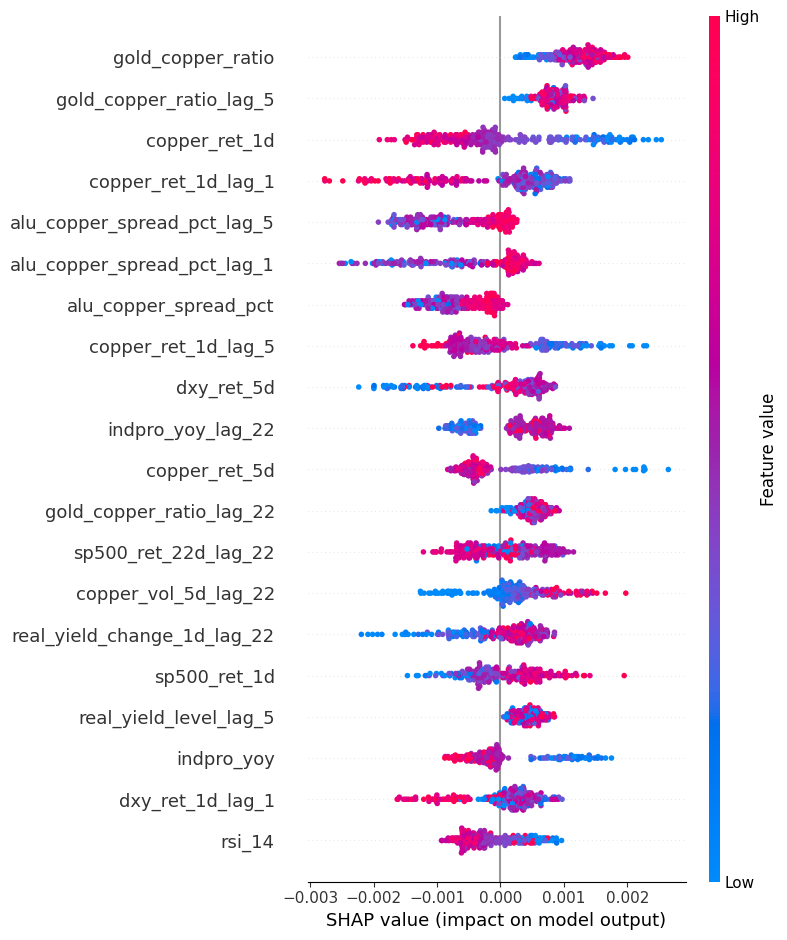

SHAP beeswarm saved to /kaggle/working/outputs/shap_beeswarm.png
Top 10 features by mean |SHAP|:
gold_copper_ratio              0.001190
gold_copper_ratio_lag_5        0.000834
copper_ret_1d                  0.000816
copper_ret_1d_lag_1            0.000780
alu_copper_spread_pct_lag_5    0.000714
alu_copper_spread_pct_lag_1    0.000683
alu_copper_spread_pct          0.000647
copper_ret_1d_lag_5            0.000622
dxy_ret_5d                     0.000615
indpro_yoy_lag_22              0.000538


In [28]:
try:
    import shap, matplotlib.pyplot as plt
    shap.initjs()

    xgb_shap = make_xgb()
    xgb_shap.fit(X_dev_pruned, y_dev)
    explainer = shap.TreeExplainer(xgb_shap._model)
    shap_values = explainer.shap_values(X_hold_pruned)

    fig_shap = plot_shap_summary(shap_values, list(X_hold_pruned.columns), top_n=20)
    fig_shap.show()

    shap.summary_plot(shap_values, X_hold_pruned, max_display=20, show=False)
    plt.tight_layout()
    _bp = os.path.join(CFG['output_dir'], 'shap_beeswarm.png')
    plt.savefig(_bp, dpi=150, bbox_inches='tight'); plt.show()
    print(f'SHAP beeswarm saved to {_bp}')

    mean_abs_shap = pd.Series(
        np.abs(shap_values).mean(axis=0), index=X_hold_pruned.columns
    ).sort_values(ascending=False)
    print('Top 10 features by mean |SHAP|:')
    print(mean_abs_shap.head(10).to_string())
except Exception as e:
    print(f'SHAP skipped: {e}')


## 12. Interactive Plotly Visualisations

In [29]:
best_cv_df = cv_results[best_name]
fig_dashboard = plot_dashboard(df_aug, best_cv_df, model_name=best_name)
fig_dashboard.show()

# Rolling signal Sharpe (best OOS model)
best_oos_name = oos_summary['rmse'].idxmin()
oos_best = oos_results[best_oos_name]
signal_ret_oos = np.sign(oos_best['y_pred']) * oos_best['y_true']
rolling_sharpe = (
    signal_ret_oos.rolling(60).mean() /
    signal_ret_oos.rolling(60).std().replace(0, np.nan)
) * np.sqrt(252 / CFG['forecast_horizon'])

fig_sharpe = go.Figure(go.Scatter(
    x=rolling_sharpe.index, y=rolling_sharpe,
    name='Rolling Sharpe (60-day)', line=dict(color='#b87333'),
))
fig_sharpe.add_hline(y=0, line_width=1, line_dash='dash', line_color='grey')
fig_sharpe.update_layout(
    title=f'Rolling 60-Day Signal Sharpe — {best_oos_name}',
    template='plotly_white', yaxis_title='Annualised Sharpe ratio',
)
fig_sharpe.show()

## 13. Scenario Analysis

In [30]:
latest_features = X_pruned_full.tail(1)
current_copper  = float(df_aug['copper_price'].iloc[-1])

scenario_model = EnsembleModel([make_xgb(), make_lgb()])
scenario_model.fit(X_dev_pruned, y_dev)

engine = ScenarioEngine(
    model=scenario_model,
    feature_template=latest_features,
    copper_price_current=current_copper,
    horizon=CFG['forecast_horizon'],
)
print(f'Current copper price    : ${current_copper:,.0f}/t')
print(f'Baseline {CFG["forecast_horizon"]}-day forecast: ${engine.base_price:,.0f}/t')

scenario_report = engine.report()
print('\n── Scenario Report ──')
print(scenario_report.to_string())

fig_tornado = plot_scenario_tornado(
    base_forecast=engine.base_price,
    scenario_results={row.Index: row.scenario_price for row in scenario_report.itertuples()},
)
fig_tornado.show()

# DXY sensitivity sweep
dxy_shocks = np.linspace(-0.10, 0.10, 21)
sweep_dxy  = engine.sweep('dxy_ret_22d', dxy_shocks.tolist(), label='DXY 22d return shock')
fig_sweep  = go.Figure(go.Scatter(
    x=sweep_dxy['shock'], y=sweep_dxy['forecast_price'],
    mode='lines+markers', line=dict(color='#b87333'), name='Forecast price',
))
fig_sweep.add_hline(y=engine.base_price, line_dash='dash', line_color='grey',
                    annotation_text='Baseline')
fig_sweep.update_layout(
    title='Copper Price Sensitivity to DXY Return Shock',
    xaxis_title='DXY 22d return shock (additive)',
    yaxis_title='Forecast Copper Price ($/t)',
    template='plotly_white',
)
fig_sweep.show()

# Custom geopolitical / tariff shock
result = engine.run('geo_tariff_shock', shocks={
    'dxy_ret_22d': 0.04, 'sp500_ret_22d': -0.08,
    'copper_vol_22d': 0.05, 'real_yield_change_22d': 0.3,
})
print('\nCustom scenario result:')
for k, v in result.items():
    print(f'  {k}: {v}')


INFO | Scenario 'bull_strong': base=12603  forecast=12609  delta=+6 (0.0%)
INFO | Scenario 'bear_strong': base=12603  forecast=12587  delta=-17 (-0.1%)
WARNING | Shock target 'cny_usd_level' not in feature set — skipped.
INFO | Scenario 'china_demand_surge': base=12603  forecast=12602  delta=-1 (-0.0%)
INFO | Scenario 'supply_disruption': base=12603  forecast=12598  delta=-5 (-0.0%)
INFO | Scenario 'comex_inventory_drop_40pct': base=12603  forecast=12599  delta=-5 (-0.0%)
WARNING | Shock target 'infl_be_level' not in feature set — skipped.
INFO | Scenario 'high_inflation': base=12603  forecast=12617  delta=+14 (0.1%)
INFO | Scenario 'us_tariff_shock': base=12603  forecast=12585  delta=-18 (-0.1%)


Current copper price    : $12,526/t
Baseline 1-day forecast: $12,603/t

── Scenario Report ──
                            base_price  scenario_price  delta  delta_pct
scenario                                                                
us_tariff_shock               12603.36        12585.19 -18.17      -0.14
bear_strong                   12603.36        12586.54 -16.82      -0.13
comex_inventory_drop_40pct    12603.36        12598.77  -4.60      -0.04
supply_disruption             12603.36        12597.97  -5.39      -0.04
china_demand_surge            12603.36        12602.37  -0.99      -0.01
bull_strong                   12603.36        12608.93   5.57       0.04
high_inflation                12603.36        12617.13  13.77       0.11


INFO | Scenario 'geo_tariff_shock': base=12603  forecast=12579  delta=-25 (-0.2%)



Custom scenario result:
  scenario: geo_tariff_shock
  base_price: 12603.36
  scenario_price: 12578.54
  delta: -24.82
  delta_pct: -0.2


## 14. Export Results

In [31]:
import json
from datetime import date

out_dir = CFG['output_dir']

forecast_df.reset_index().rename(columns={'index': 'date'}).to_csv(
    os.path.join(out_dir, 'forecast_ci.csv'), index=False
)

for name, df_oos in oos_results.items():
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '')
    df_oos.to_csv(os.path.join(out_dir, f'oos_{safe_name}.csv'))

oos_summary.to_csv(os.path.join(out_dir, 'model_comparison.csv'))
scenario_report.to_csv(os.path.join(out_dir, 'scenario_report.csv'))
coint_df.to_csv(os.path.join(out_dir, 'cointegration_results.csv'))

summary_json = {
    'generated_at':      date.today().isoformat(),
    'current_price':     round(current_copper, 2),
    'baseline_forecast': round(engine.base_price, 2),
    'horizon_days':      CFG['forecast_horizon'],
    'best_model':        best_oos_name,
    'oos_metrics':       oos_metrics[best_oos_name],
    'scenarios':         scenario_report.reset_index().to_dict(orient='records'),
}
with open(os.path.join(out_dir, 'forecast_summary.json'), 'w') as f:
    json.dump(summary_json, f, indent=2)

print(f'All outputs saved to {out_dir}/')
print('Files:', os.listdir(out_dir))

All outputs saved to /kaggle/working/outputs/
Files: ['oos_Linear_Ridge.csv', 'forecast_summary.json', 'oos_EnsembleXGBoost+LightGBM.csv', 'oos_Naive_RW.csv', 'forecast_ci.csv', 'oos_HybridARIMAX+LightGBM.csv', 'cointegration_results.csv', 'shap_beeswarm.png', 'oos_LightGBM.csv', 'oos_Prophet.csv', 'scenario_report.csv', 'model_comparison.csv', 'oos_XGBoost.csv', 'oos_ARIMAX.csv']


---
## Summary

| Optimisation | Detail |
|---|---|
| **GPU acceleration** | XGBoost `device='cuda'`, LightGBM `device='gpu'` when T4/P100 is detected |
| **Parallel Optuna** | `n_jobs=N_JOBS` → all CPU cores used per tuning study |
| **Parallel CV folds** | `compare_models(n_jobs=N_JOBS)` → folds run concurrently via joblib |
| **Data cache** | Pickle cache keyed by date + API keys — restarted sessions load instantly |
| **Kaggle secrets** | FRED & Nasdaq API keys loaded from Kaggle Secrets, never hard-coded |
| **Shallow clone** | `git clone --depth 1` downloads only the latest commit |

Expected runtimes on Kaggle (GPU T4 x2, Internet on):

| Section | ~Time |
|---|---|
| Clone + install | 2–3 min (first run) / <10 s (cached) |
| Data download | 1–2 min (first run) / instant (cached) |
| Feature engineering | ~30 s |
| Optuna tuning (50 trials each) | ~5 min |
| Walk-forward CV (all models) | ~8–12 min |
| OOS backtest | ~3–5 min |
| SHAP + visualisations | ~2 min |
| **Total** | **~25–35 min** (vs ~60–90 min on CPU-only) |

In [38]:
# ── Email forecast results after pipeline run ────────────────────────────────
import smtplib, os
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.base import MIMEBase
from email import encoders

def send_email_with_attachments(sender_email, sender_password, receiver_email,
                                subject, body, file_paths):
    msg = MIMEMultipart()
    msg['From']    = sender_email
    msg['To']      = receiver_email
    msg['Subject'] = subject
    msg.attach(MIMEText(body, 'plain'))

    for file_path in file_paths:
        if not os.path.exists(file_path):
            print(f'  Skipping missing attachment: {file_path}')
            continue
        with open(file_path, 'rb') as f:
            part = MIMEBase('application', 'octet-stream')
            part.set_payload(f.read())
        encoders.encode_base64(part)
        part.add_header('Content-Disposition',
                        f'attachment; filename={os.path.basename(file_path)}')
        msg.attach(part)

    with smtplib.SMTP_SSL('smtp.gmail.com', 465) as server:
        server.login(sender_email, sender_password)
        server.send_message(msg)
    print(f'Email sent to {receiver_email}')


def save_figure(fig, png_path):
    """Save a Plotly figure as PNG, falling back to HTML if kaleido is unavailable."""
    try:
        fig.write_image(png_path, scale=2)
        print(f'Saved {os.path.basename(png_path)}')
        return png_path
    except Exception as e:
        print(f'Could not save {os.path.basename(png_path)}: {e}')
        html_path = png_path.replace('.png', '.html')
        fig.write_html(html_path)
        print(f'  Saved fallback {os.path.basename(html_path)}')
        return html_path


# ── Save forecast figures as PNG (HTML fallback if kaleido unavailable) ───────
out_dir = CFG['output_dir']

saved_fc  = save_figure(fig_fc,  os.path.join(out_dir, 'forecast_ci.png'))
saved_cmp = save_figure(fig_cmp, os.path.join(out_dir, 'model_comparison.png'))
saved_cv  = save_figure(fig_cv,  os.path.join(out_dir, 'cv_best_model.png'))

# ── Load email credentials from Kaggle Secrets ───────────────────────────────
try:
    from kaggle_secrets import UserSecretsClient
    _secrets        = UserSecretsClient()
    sender_email    = _secrets.get_secret('GMAIL_ADDRESS')
    sender_password = _secrets.get_secret('GMAIL_APP_PASSWORD')
except Exception as e:
    raise RuntimeError(f'Email secrets not found — add GMAIL_ADDRESS and GMAIL_APP_PASSWORD to Kaggle Secrets. ({e})')

email_body = (
    f'Copper Forecast Pipeline complete.\n'
    f'Best CV model   : {best_name}\n'
    f'Best OOS model  : {best_oos_name}\n'
    f'Current price   : ${current_copper:,.0f}/t\n'
    f'Baseline forecast ({CFG["forecast_horizon"]}-day): ${engine.base_price:,.0f}/t\n\n'
    'Attachments: forecast CI chart, model comparison, CV folds, SHAP beeswarm.'
)

send_email_with_attachments(
    sender_email    = sender_email,
    sender_password = sender_password,
    receiver_email  = sender_email,
    subject         = 'Copper Forecast — Daily Update',
    body            = email_body,
    file_paths      = [
        saved_fc,
        saved_cmp,
        saved_cv,
        os.path.join(out_dir, 'shap_beeswarm.png'),
    ],
)


Could not save forecast_ci.png: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

  Saved fallback forecast_ci.html
Could not save model_comparison.png: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

  Saved fallback model_comparison.html
Could not save cv_best_model.png: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

  Saved fallback cv_best_model.html
Email sent to ferhat00@gmail.com
